In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib import patches as pat
from matplotlib import transforms
from matplotlib.collections import PatchCollection
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from joblib import load, dump
import re
import scipy.cluster.hierarchy as sch

# custom code
import figutils
sys.path.insert(
    0, os.path.abspath('../2021_07_31_custom_adjacency_regularization/'))
import sequence_logo
from quad_model import *
import kl
import force
from scipy.stats import gaussian_kde

sys.path.insert(
    0, os.path.abspath('../2021_11_21_full_data_preprocessing_HeLA/'))
import read_datasets

from collections.abc import Iterable

%matplotlib inline

2022-09-11 19:31:45.419194: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64:/.singularity.d/libs
2022-09-11 19:31:45.419214: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
Matplotlib is building the font cache; this may take a moment.


In [3]:
plt.style.use('/home/ms7490/scratch/code/scratch/matplotlib/clean.mplstyle')

# Load data and models

In [4]:
xTr = load(f'../2021_07_31_custom_adjacency_regularization/data/xTr_ES7_HeLa_ABC.pkl')
yTr = load(f'../2021_07_31_custom_adjacency_regularization/data/yTr_ES7_HeLa_ABC.pkl')
xTe = load(f'../2021_07_31_custom_adjacency_regularization/data/xTe_ES7_HeLa_ABC.pkl')
yTe = load(f'../2021_07_31_custom_adjacency_regularization/data/yTe_ES7_HeLa_ABC.pkl')

In [5]:
def binary_KL(y_true, y_pred):
    return tf.keras.backend.mean(
        tf.keras.backend.binary_crossentropy(y_true, y_pred)
        - tf.keras.backend.binary_crossentropy(y_true, y_true),
        axis=-1,
    )

In [6]:
yTe_hat_gru = load('../2021_10_25_gru/data/yPredTe.pkl')
binary_KL(tf.Variable(yTe.astype(float)), tf.Variable(yTe_hat_gru.flatten().astype(float)))

2022-09-02 13:13:50.773276: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64:/.singularity.d/libs
2022-09-02 13:13:50.773297: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2022-09-02 13:13:50.773315: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (cm011.hpc.nyu.edu): /proc/driver/nvidia/version does not exist
2022-09-02 13:13:50.773538: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


<tf.Tensor: shape=(), dtype=float64, numpy=0.08475779242909424>

In [7]:
model_fname = f'../2021_07_31_custom_adjacency_regularization/models/custom_adjacency_regularizer_20210731_124_step3.h5'
model = tf.keras.models.load_model(model_fname)

In [8]:
model.evaluate(xTe, yTe)

2022-08-08 15:18:38.542935: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


1499/1499 [==============================] - 11s 7ms/step - loss: 0.1249 - binary_KL: 0.0999


[0.12492550909519196, 0.09990660846233368]

In [9]:
num_seq_filters = model.get_layer('qc_incl').kernel.shape[2]
num_struct_filters = model.get_layer('c_incl_struct').kernel.shape[2]

position_bias_size = model.get_layer('position_bias_incl').kernel.shape[0]
struct_filter_width = model.get_layer("c_incl_struct").kernel.shape[0]
input_length = model.input[0].shape[1]

# Figure 1c

In [10]:
all_barcode_statistics = read_datasets.read_all_datasets_no_filtering()

In [11]:
NUM_SPLICING_OUTCOMES = 7
summary_data = [[] for i in range(NUM_SPLICING_OUTCOMES)]
for lib_num in [11, 12, 13]:
    barcode_statistics = all_barcode_statistics[lib_num]
    statistics = barcode_statistics[barcode_statistics.badly_coupled == False].drop(columns=["exon","num_dna_reads"]).sum()
    statistics = 100*statistics/statistics.sum()
    summary_data[0].append(statistics.num_exon_inclusion)
    summary_data[1].append(statistics.num_exon_skipping)
    summary_data[2].append(statistics.num_splicing_in_exon)
    summary_data[3].append(statistics.num_unknown_splicing)
    summary_data[4].append(statistics.num_bad_exon1)
    summary_data[5].append(statistics.num_bad_reads)
    summary_data[6].append(statistics.num_intron_retention)

In [12]:
all_barcode_statistics[11].columns

Index(['exon', 'badly_coupled', 'num_dna_reads', 'num_intron_retention',
       'num_exon_inclusion', 'num_exon_skipping', 'num_bad_reads',
       'num_bad_exon1', 'num_splicing_in_exon', 'num_unknown_splicing'],
      dtype='object')

In [13]:
(all_barcode_statistics[11].iloc[:, 2:].sum(axis=1).mean(),
    all_barcode_statistics[12].iloc[:, 2:].sum(axis=1).mean(),
        all_barcode_statistics[13].iloc[:, 2:].sum(axis=1).mean())

(66.66342184352192, 54.67300494291973, 59.16279709809879)

In [14]:
summary_data_names = ['Exon inclusion', 'Exon skipping', 'Splicing in exon',
                      'Unidentified splicing products', 'Exon 1 unidentified', 'N in read', 'Intron 1 retention']

In [15]:
summary_data = np.array(summary_data)

In [16]:
# collapse summary data

summary_data = pd.DataFrame(summary_data, index=summary_data_names, columns=['Rep 1', 'Rep 2', 'Rep 3']).T

In [17]:
summary_data['Other'] = summary_data[['Splicing in exon',
                      'Unidentified splicing products', 'Exon 1 unidentified', 'N in read', 'Intron 1 retention']].sum(axis=1)

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


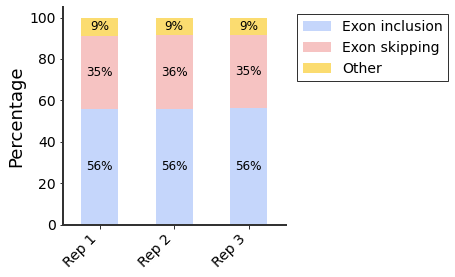

In [18]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#C5D6FB", '#F6C3C2', '#fbdc70', '#c1efb2', '#dcd7f1', 'yellow', 'black', 'purple',
                                             'pink', 'brown', 'orange', 'teal', 'coral', 'lightblue', 'lime', 'lavender', 'turquoise', 'darkgreen', 'tan', 'salmon', 'gold'])
fig, ax = plt.subplots(figsize=(6/1.5, 6/1.5))
totals = np.zeros(3)
# plots = []
# for idx, row in enumerate(summary_data):
#     plots.append(ax.bar(np.arange(len(row)), row, bottom=totals))
#     totals += row

summary_data[['Exon inclusion', 'Exon skipping', 'Other']].plot.bar(stacked=True, ax=ax)

prevs = np.zeros(3)
for idx, rep_row in enumerate(summary_data[['Exon inclusion', 'Exon skipping', 'Other']].values):
    for jdx, val in enumerate(rep_row):
        ax.text(idx, prevs[idx] + val / 2, f'{val:.0f}%', ha='center', va='center', fontsize=12, rotation=0)
        prevs[idx] += val

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Rep 1', 'Rep 2', 'Rep 3'], rotation=45, ha='right')
# ax.legend(reversed([plots[i][0] for i in range(7)]), reversed(['Exon inclusion', 'Exon skipping', 'Splicing in exon',
#           'Unidentified splicing products', 'Exon 1 unidentified', 'N in read', 'Intron 1 retention']), loc='upper left', bbox_to_anchor=(1.02, 1))
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_ylabel('Percentage')



fig.savefig('./figs/figure_1c.svg', pad_inches=0.1,
            bbox_inches='tight')
fig.savefig('./figs/figure_1c.pdf', pad_inches=0.1,
            bbox_inches='tight')

# Extended figure 1a

In [6]:
def to_target_data(df):
    return np.array(df.num_exon_inclusion /
                    (df.num_exon_inclusion + df.num_exon_skipping))

In [7]:
lib_nums = [11, 12, 13]
MIN_READS = 20

In [21]:
datasets = {}

In [22]:
for lib_num in lib_nums:
    dataset = all_barcode_statistics[lib_num]
    dataset[
    "others"] = dataset.num_unknown_splicing + dataset.num_intron_retention + dataset.num_bad_reads + dataset.num_bad_exon1
    dataset[
        "total"] = dataset.others + dataset.num_exon_skipping + dataset.num_exon_inclusion + dataset.num_splicing_in_exon
    
#     dataset = dataset[
#         dataset.num_exon_skipping +
#         dataset.num_exon_inclusion >= MIN_READS]
    
#     dataset = dataset[
#         (dataset.num_exon_inclusion +
#          dataset.num_exon_skipping) /
#         dataset.total > 0.8]
    
    dataset['psi'] = to_target_data(dataset)
    
    datasets[lib_num] = dataset

In [23]:
merged_data = datasets[11].join(datasets[12], lsuffix='_11', how='inner').join(datasets[13], lsuffix='_12', rsuffix='_13', how='inner')

In [37]:
merged_data = merged_data.dropna()

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


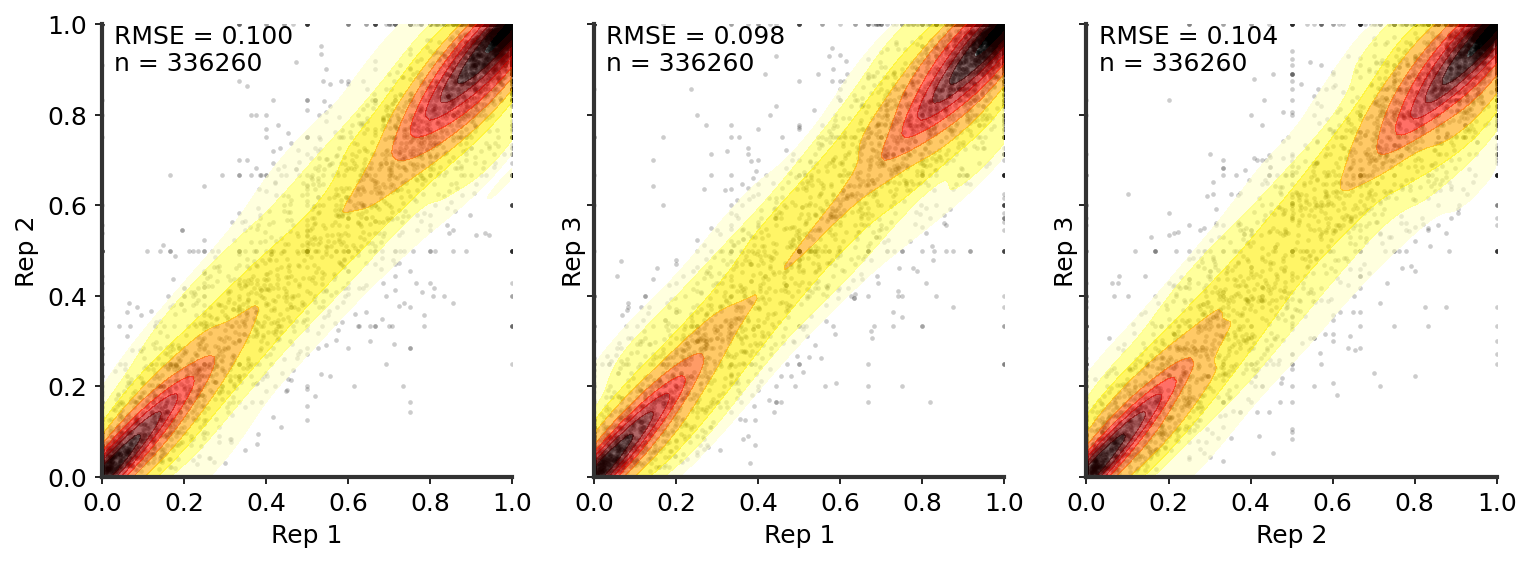

In [38]:
fig, axarr = plt.subplots(1, 3, figsize=(12, 4), dpi=150, sharex=True, sharey=True)

axarr = np.array([[axarr[0], np.nan], [axarr[1], axarr[2]]])

plot_data = [
    {'left': 12, 'right': 11, 'row':0, 'col':0},
    {'left': 13, 'right': 11, 'row':1, 'col':0},
    {'left': 13, 'right': 12, 'row':1, 'col':1}
]

rep_lookup = {11:1, 12:2, 13:3}

for plot_dict in plot_data:
    left_data = merged_data[f"psi_{plot_dict['left']}"].values
    right_data = merged_data[f"psi_{plot_dict['right']}"].values
    
    ax = axarr[plot_dict['row'], plot_dict['col']]
    
    x, y = figutils.subsample_points(left_data, right_data, max_points=10000)
    x, y = y, x
    xy = np.vstack([x,y])
    kde = gaussian_kde(xy)
    z = kde(xy)
    
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    cont = axarr[plot_dict['row'], plot_dict['col']].scatter(x, y, alpha=0.2, s=5,
                                                             cmap=plt.cm.hot_r, linewidth=0., c='k')
    
    grid_resolution = 100
    A, B = np.meshgrid(np.linspace(0, 1, grid_resolution), np.linspace(0, 1, grid_resolution))
    xygrid = np.vstack([A.flatten(), B.flatten()])
    zgrid = kde(xygrid)
    
    ax.contourf(A, B,
                np.log(zgrid).reshape(*A.shape), 10000, origin='lower',
                cmap=plt.cm.hot_r, alpha=0.6, levels=np.linspace(-2, 3, 10))
    
    rmse = np.sqrt(((left_data - right_data) ** 2).mean())
    ax.set_xlabel(f"Rep {rep_lookup[plot_dict['right']]}", fontsize=12)
    ax.set_ylabel(f"Rep {rep_lookup[plot_dict['left']]}", fontsize=12)
    ax.text(3e-2, 1., f'RMSE = {rmse:.3f}\nn = {left_data.shape[0]}', ha='left', fontsize=12, va='top')
    
# axarr[0, 1].axis('off')

for axrow in axarr:
    for ax in axrow:
        if not isinstance(ax, float):
            ax.tick_params(axis='x', labelsize=12)
            ax.tick_params(axis='y', labelsize=12)

fig.savefig('./figs/extended_figure_1a.svg', pad_inches=0.1,
            bbox_inches='tight')
fig.savefig('./figs/extended_figure_1a.pdf', pad_inches=0.1,
            bbox_inches='tight')

# Figure 1b

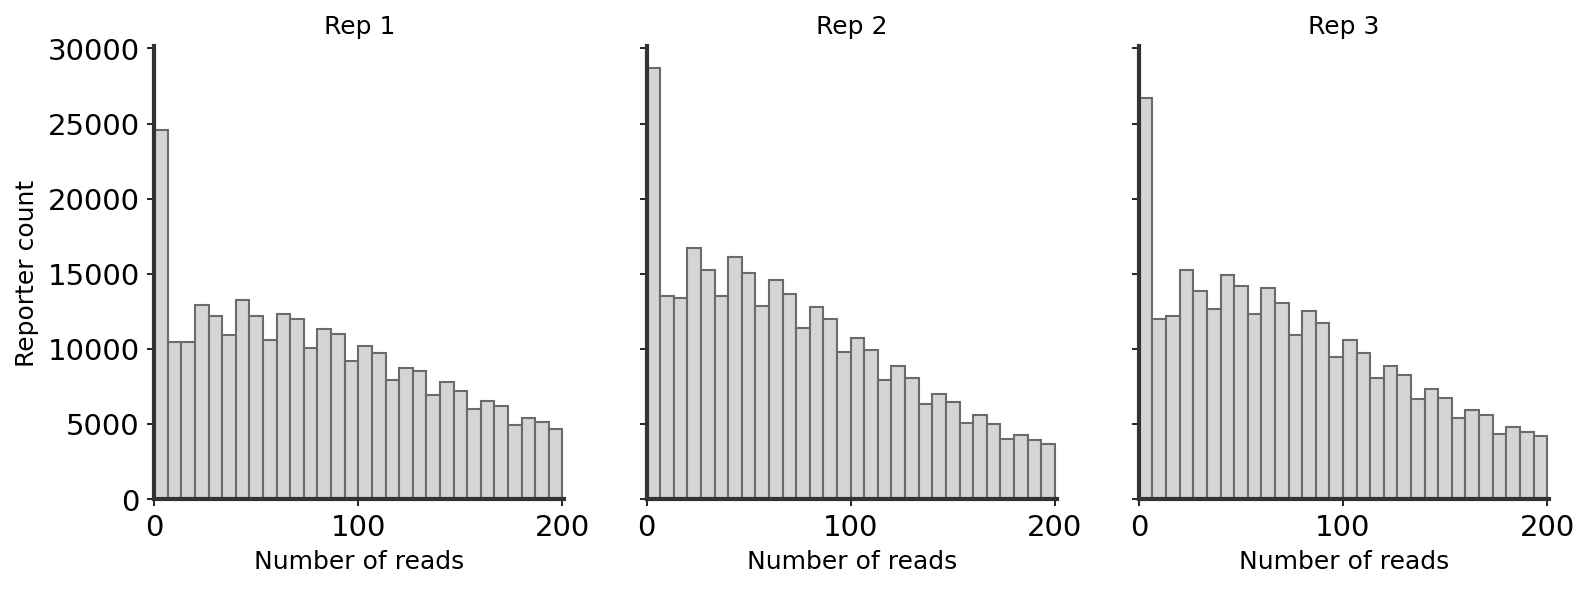

In [25]:
fig, axarr = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True, dpi=150)

titles = [f'Rep {i}' for i in [1, 2, 3]]
for idx, i in enumerate([11, 12, 13]):
    barcode_statistics = all_barcode_statistics[i]
    statistics = barcode_statistics[barcode_statistics.badly_coupled == False].drop(
        columns=["exon", "num_dna_reads"])
    # filter only barcodes with enough reads
    statistics["total_reads"] = statistics.sum(axis=1)
    # statistics = statistics.query('total_reads > 0')

    axarr[idx].hist(statistics.total_reads, bins=30, range=(
        0, 200), density=False, linewidth=1, edgecolor='#6b6b6b', color='#d5d5d5')

    axarr[idx].set_xlabel('Number of reads', fontsize=12)
    axarr[idx].set_title(f'{titles[i-11]}', fontweight='normal', fontsize=12)
    axarr[idx].set_xlim(0, 201)
axarr[0].set_ylabel('Reporter count', fontsize=12)


fig.savefig('./figs/figure_1b.svg', pad_inches=0.1,
            bbox_inches='tight')
fig.savefig('./figs/figure_1b.pdf', pad_inches=0.1,
            bbox_inches='tight')

# Figure 1d

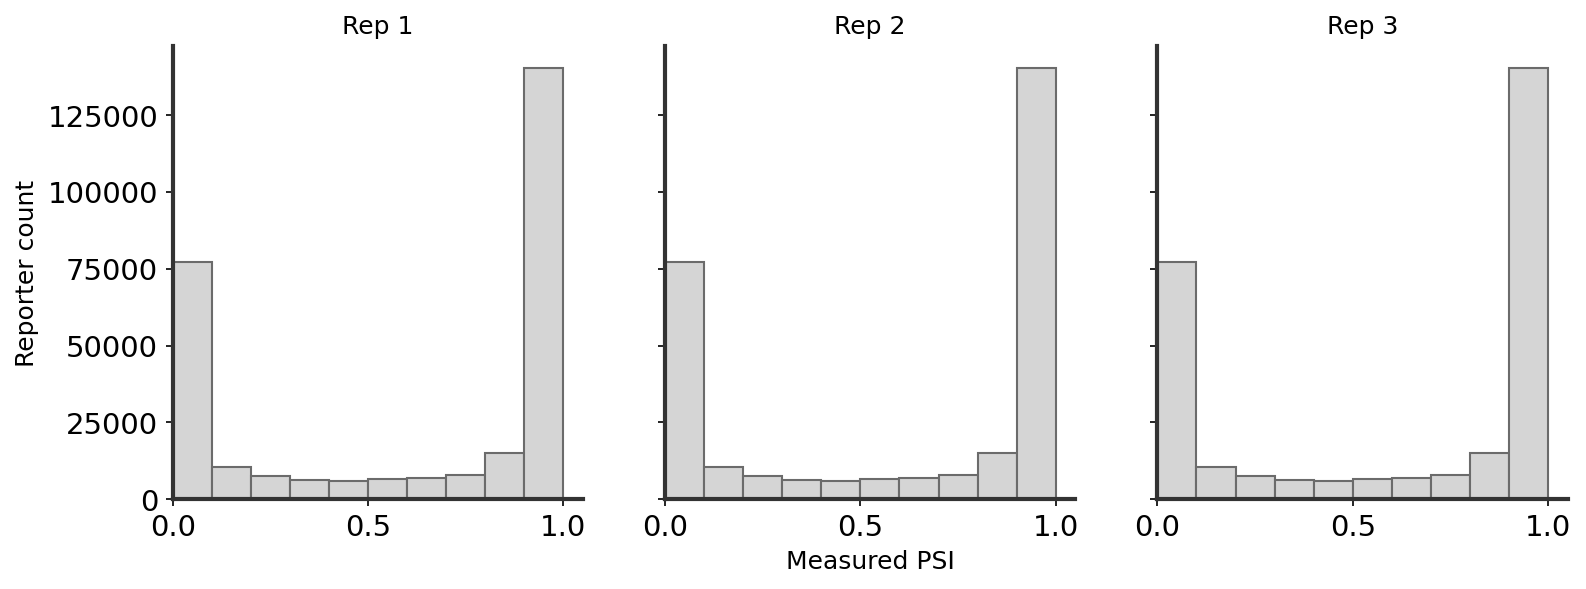

In [26]:
fig, axarr = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True, dpi=150)
MIN_NUM_READS = 10

for idx, i in enumerate([11, 12, 13]):
    barcode_statistics = all_barcode_statistics[lib_num]
    statistics = barcode_statistics[barcode_statistics.badly_coupled == False].drop(columns=["exon","num_dna_reads"])
    # filter only barcodes with enough reads
    statistics = statistics[statistics.num_exon_inclusion + statistics.num_exon_skipping > MIN_NUM_READS]
    statistics["PSI"] = statistics.num_exon_inclusion / (statistics.num_exon_inclusion + statistics.num_exon_skipping)
    
    axarr[idx].hist(statistics.PSI, density=False, linewidth=1, edgecolor='#6b6b6b', color='#d5d5d5')
    
    
    axarr[idx].set_title(f'{titles[i-11]}', fontweight='normal', fontsize=12)
    axarr[idx].set_xlim(0, 1.05)
axarr[1].set_xlabel('Measured PSI', fontsize=12)
axarr[0].set_ylabel('Reporter count', fontsize=12)

fig.savefig('./figs/figure_1d.svg', pad_inches=0.1,
    bbox_inches='tight')
fig.savefig('./figs/figure_1d.pdf', pad_inches=0.1,
    bbox_inches='tight')

In [27]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

In [28]:
all_psis = []

for idx, i in enumerate([11, 12, 13]):
    barcode_statistics = all_barcode_statistics[lib_num]
    statistics = barcode_statistics[barcode_statistics.badly_coupled == False].drop(columns=["exon","num_dna_reads"])
    # filter only barcodes with enough reads
    statistics = statistics[statistics.num_exon_inclusion + statistics.num_exon_skipping > MIN_NUM_READS]
    statistics["PSI"] = statistics.num_exon_inclusion / (statistics.num_exon_inclusion + statistics.num_exon_skipping)
    
    all_psis.append(statistics.PSI.copy())

In [29]:
rmse_grid = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        rmse_grid[i,j] = rmse(all_psis[i], all_psis[j])

# Lorenz plot

In [30]:
all_couplings = load('../2021_11_21_full_data_preprocessing_HeLA/data/all_couplings_Sample_BS06911A.pkl')

In [31]:
couplings = all_couplings[0]

In [32]:
barcodes_with_counts = [[x, sum(couplings[x][0].values())] for x in couplings.keys()]

In [33]:
df = pd.DataFrame(barcodes_with_counts, columns = ['barcode', 'cnt'])

In [34]:
df_filtered = df[df["cnt"] > 1]
t = np.cumsum(list(reversed(sorted(list(df_filtered["cnt"])))))

In [35]:
t = t/t[-1]

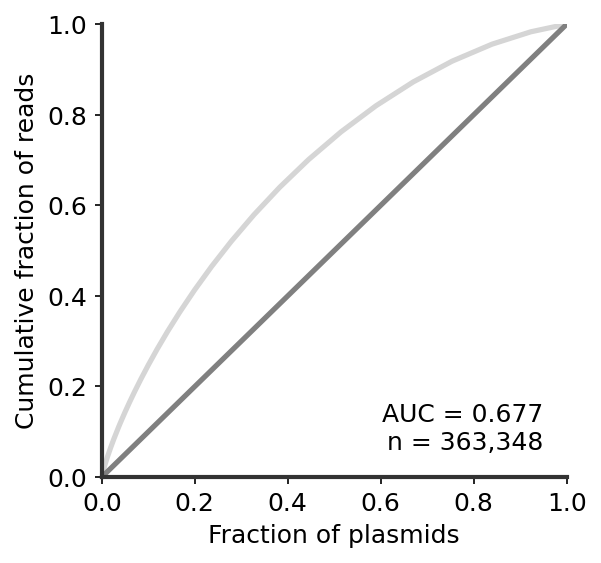

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), sharex=True, sharey=True, dpi=150)

ax.plot([i/len(t) for i in range(len(t))], t, color='#d5d5d5') 
# ax.set_xticks(np.arange(0,len(t),100000))
ax.set_xlabel("Fraction of plasmids", fontsize=12)
ax.set_ylabel("Cumulative fraction of reads", fontsize=12)
ax.text(0.95, 0.05,f'AUC = 0.677\nn = 363,348', ha='right', va='bottom',
        transform=ax.transAxes, fontsize=12)
ax.plot([0, 1],color='gray')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.margins(y=0, x=0)

fig.savefig('./figs/lorenz.svg', pad_inches=0.1,
    bbox_inches='tight')
fig.savefig('./figs/lorenz.pdf', pad_inches=0.1,
    bbox_inches='tight')

plt.show()